<a href="https://colab.research.google.com/github/IamFonky/Cours/blob/main/biais_genre_word_embedding_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP — Détecter les biais de genre dans une IA

Dans ce TP, vous allez explorer un véritable modèle d'IA appelé **GloVe**, qui sait représenter le sens des mots sous forme de vecteurs mathématiques. Vous allez chercher s'il contient des biais de genre, et si oui, comprendre d'où ils viennent.

> ⚠️ **Important** : le modèle utilisé a été entraîné sur des textes en **anglais** (Wikipédia anglophone et corpus de news Gigaword). Toutes les requêtes que nous lui ferons devront donc être faites avec des **mots anglais** : on cherchera la similarité entre `"woman"` et `"doctor"`, pas entre `"femme"` et `"médecin"`.

**Plan du TP :**
1. Installation et chargement du modèle
2. *Activité 1* — Premières observations
3. *Activité 2* — Les métiers ont-ils un genre ?
4. *Activité 3* — Visualisation et exploration libre
5. *Activité 4* — Les analogies vectorielles
6. *Activité 5* — Tentative de débiaisage
7. Conclusion


## 1. Installation des bibliothèques

Nous avons besoin de deux bibliothèques Python :
- **`gensim`** : permet de manipuler des modèles de word embeddings pré-entraînés.
- **`matplotlib`** : permet de tracer des graphiques.

In [28]:
!pip install matplotlib numpy scikit-learn gensim

### Importation des outils

On charge ensuite les modules que nous allons utiliser dans la suite du TP.


In [29]:
# Pour tracer des graphiques (diagrammes en barres, nuages de points, etc.)
import matplotlib.pylab as plt

# Pour faire des calculs sur des vecteurs (additionner, normaliser...)
import numpy as np

# Pour projeter des vecteurs de grande dimension en 2D (visualisation)
from sklearn.manifold import TSNE

# Pour télécharger des modèles d'IA pré-entraînés
from gensim import downloader

## 2. Téléchargement d'un modèle

Nous allons utiliser **GloVe** (*Global Vectors for Word Representation*), un modèle développé à l'Université de Stanford.
Il associe à chaque mot anglais courant un vecteur de **100 nombres**.
Ces vecteurs ont été appris à partir de l'intégralité de Wikipédia anglophone et d'un grand corpus de news (~6 milliards de mots).

⏳ Le téléchargement du plus petit modèle fait environ 130 Mo et prend quelques minutes la première fois.

In [ ]:
# Téléchargement et chargement d'un modèle de word embeddings pré-entraîné.
# Pour utiliser un autre modèle, dé-commentez sa ligne (et commentez l'actuelle).
#
# Le modèle est mis en cache localement : le téléchargement n'a lieu qu'une fois.
# Temps estimés sur une connexion type Google Colab (~5 Mo/s) ; peuvent varier.

# === GloVe — Wikipédia 2014 + Gigaword 5 (anglais, 6 milliards de mots, vocabulaire de 400 000 mots) ===
# modele = downloader.load('glove-wiki-gigaword-50')              #  50 dim |   65 Mo | ~ 30 s    — plus léger, qualité moindre
modele = downloader.load('glove-wiki-gigaword-100')             # 100 dim |  128 Mo | ~ 50 s    —  recommandé pour ce TP
# modele = downloader.load('glove-wiki-gigaword-200')             # 200 dim |  252 Mo | ~ 1.5 min — meilleure qualité
# modele = downloader.load('glove-wiki-gigaword-300')             # 300 dim |  376 Mo | ~ 2.5 min — haute qualité

# === GloVe — Twitter (anglais, 2 milliards de tweets, langage de réseau social) ===
# Idéal pour COMPARER les biais entre Wikipédia (encyclopédique) et Twitter (informel).
# modele = downloader.load('glove-twitter-25')                    #  25 dim |  104 Mo | ~ 40 s
# modele = downloader.load('glove-twitter-50')                    #  50 dim |  199 Mo | ~ 1 min
# modele = downloader.load('glove-twitter-100')                   # 100 dim |  387 Mo | ~ 2.5 min
# modele = downloader.load('glove-twitter-200')                   # 200 dim |  758 Mo | ~ 5 min

# === Word2Vec — Google News (anglais, 100 milliards de mots, vocabulaire de 3 millions) ===
# Très grand vocabulaire (inclut beaucoup de noms propres), mais long à télécharger.
# modele = downloader.load('word2vec-google-news-300')            # 300 dim |  1.6 Go | ~ 10-12 min

# === FastText — Wikipédia 2017 + News (anglais, 16 milliards de mots) ===
# Algorithme alternatif : utilise les sous-mots, donc plus robuste aux mots rares ou mal orthographiés.
# modele = downloader.load('fasttext-wiki-news-subwords-300')     # 300 dim |  958 Mo | ~ 6 min

# === ConceptNet Numberbatch — combinaison de ConceptNet + word2vec + GloVe + sous-titres ===
# Très intéressant pour le TP : ce modèle a été PARTIELLEMENT DÉBIAISÉ par ses créateurs.
#    Comparer ses résultats avec ceux de GloVe permet de voir l'effet d'un débiaisage en amont.
# modele = downloader.load('conceptnet-numberbatch-17-06-300')    # 300 dim |  1.2 Go | ~ 8 min

# === Word2Vec — Corpus National Russe (RUSSE, pas anglais — les requêtes devront être en russe !) ===
# modele = downloader.load('word2vec-ruscorpora-300')             # 300 dim |  198 Mo | ~ 1 min


print("Modèle chargé avec succès !")
print(f"Nombre de mots dans le vocabulaire : {len(modele.index_to_key):,}")
print(f"Taille du vecteur de chaque mot    : {modele.vector_size} dimensions")

[======--------------------------------------------] 13.5% 223.8/1662.8MB downloaded

---
## Activité 1 — Premières observations

Pour commencer, regardons quels sont les mots les plus proches du mot **`"woman"`** dans l'espace des vecteurs.
La fonction `most_similar` renvoie les mots dont le vecteur est le plus proche d'un mot donné, accompagnés d'un score de similarité (entre 0 et 1).

> 📝 **Avant d'exécuter** : à votre avis, quels mots vont apparaître ?


In [31]:

# Les 10 mots dont le vecteur est le plus proche de celui de "woman"
modele.most_similar("woman", topn=10)

[('girl', 0.8472671508789062),
 ('man', 0.832349419593811),
 ('mother', 0.827568769454956),
 ('boy', 0.7720510363578796),
 ('she', 0.7632068395614624),
 ('child', 0.7601762413978577),
 ('wife', 0.7505022883415222),
 ('her', 0.7445706129074097),
 ('herself', 0.7426273822784424),
 ('daughter', 0.726445734500885)]

Et maintenant pour **`"man"`** :

In [32]:
# Les 10 mots dont le vecteur est le plus proche de celui de "man"
modele.most_similar("man", topn=10)

[('woman', 0.8323495388031006),
 ('boy', 0.7914870977401733),
 ('one', 0.7788748741149902),
 ('person', 0.7526816725730896),
 ('another', 0.7522234916687012),
 ('old', 0.7409117221832275),
 ('life', 0.7371697425842285),
 ('father', 0.7370322346687317),
 ('turned', 0.7347694635391235),
 ('who', 0.7345511317253113)]

> ❓ **À discuter** : qu'est-ce qui diffère entre les deux listes ? Y a-t-il un déséquilibre dans les types de mots qui apparaissent (mots de famille, d'apparence, de profession...) ?


---
## Activité 2 — Les métiers ont-ils un genre ?

Nous allons maintenant comparer la proximité entre les mots `"woman"` / `"man"` et une liste de métiers. **Plus un métier est proche d'un genre dans le modèle, plus il y a été statistiquement associé à ce genre dans les textes utilisés pour l'entraînement.**

> 📝 **Avant d'exécuter, remplissez votre tableau de prédictions sur la fiche élève** : pour chaque métier, lequel sera le plus proche de "woman", lequel de "man" ?


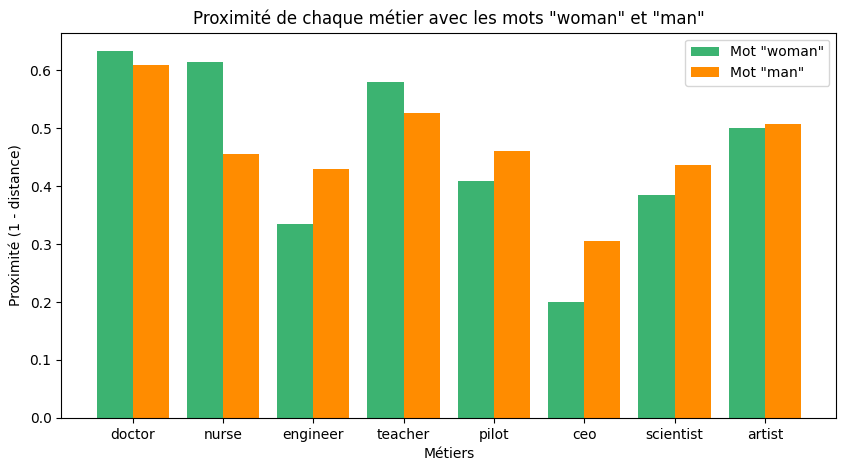

In [33]:
# Liste des métiers à tester (en anglais car le modèle est anglais)
metiers = ['doctor', 'nurse', 'engineer', 'teacher', 'pilot', 'ceo', 'scientist', 'artist']

# Calcul des distances cosinus entre "woman" / "man" et chaque métier
# Une distance de 0 = vecteurs identiques, 1 = vecteurs orthogonaux, 2 = opposés
distances_femme = modele.distances("woman", metiers)
distances_homme = modele.distances("man", metiers)

# Pour rendre le graphique plus parlant, on transforme la distance en proximité
# Plus la barre est haute, plus le métier est proche du mot
proximite_femme = 1 - distances_femme
proximite_homme = 1 - distances_homme

# Tracé du diagramme en barres comparant les deux genres
largeur = 0.4
plt.figure(figsize=(10, 5))
plt.bar(metiers, proximite_femme, -largeur, align='edge', color='mediumseagreen', label='Mot "woman"')
plt.bar(metiers, proximite_homme, +largeur, align='edge', color='darkorange',    label='Mot "man"')

plt.xlabel('Métiers')
plt.ylabel('Proximité (1 - distance)')
plt.title('Proximité de chaque métier avec les mots "woman" et "man"')
plt.legend()
plt.show()

> ❓ **À discuter** : combien de prédictions correctes avez-vous fait sur 8 ? Le modèle décrit-il le monde tel qu'il **EST**, ou tel qu'il **DEVRAIT être** ?


---
## Activité 3 — Visualisation du voisinage des mots

Chaque mot est représenté par un vecteur de taille énorme : impossible à visualiser directement.
Nous allons donc utiliser une technique appelée **t-SNE** qui projette ces vecteurs sur un plan à 2 dimensions, en essayant de préserver les distances : les mots proches dans l'espace original restent proches sur le plan.

La fonction ci-dessous prend un mot et affiche ses voisins dans ce plan 2D.


In [34]:
def afficher_voisinage_tsne(modele, mot, voisins=None, taille=50):
    """
    Projette en 2D les voisins d'un mot dans l'espace des word embeddings,
    et affiche un nuage de points avec les étiquettes de chaque mot.

    Paramètres :
    - modele  : le modèle de word embeddings
    - mot     : le mot dont on veut visualiser le voisinage
    - voisins : liste des voisins déjà calculée (optionnel) ; si None, on les calcule
    - taille  : nombre de voisins à afficher
    """
    # Si la liste des voisins n'est pas fournie, on la calcule
    if voisins is None:
        voisins = modele.similar_by_word(mot, topn=1000)

    # Construction du tableau des vecteurs : le mot lui-même + ses voisins
    dimension = len(modele[mot])
    vecteurs = np.empty((0, dimension), dtype='f')
    etiquettes = [mot]
    vecteurs = np.append(vecteurs, np.array([modele[mot]]), axis=0)

    for voisin, _score in voisins[0:taille]:
        vecteurs = np.append(vecteurs, np.array([modele[voisin]]), axis=0)
        etiquettes.append(voisin)

    # Projection en 2D avec t-SNE (la magie de la réduction de dimension)
    tsne = TSNE(n_components=2, random_state=0)
    coords = tsne.fit_transform(vecteurs)

    # Tracé du nuage de points
    plt.figure(figsize=(10, 7))
    plt.scatter(coords[:, 0], coords[:, 1])
    plt.title(f'Voisinage du mot "{mot}" projeté en 2D')

    # Ajout d'une étiquette à côté de chaque point
    for etiquette, (x, y) in zip(etiquettes, coords):
        plt.annotate(etiquette, xy=(x, y), xytext=(3, 3), textcoords='offset points')

    plt.show()

On peut maintenant afficher le voisinage de **`"woman"`** puis celui de **`"man"`**.

Observez les deux nuages : à quel champ lexical appartiennent les mots autour de chacun ?


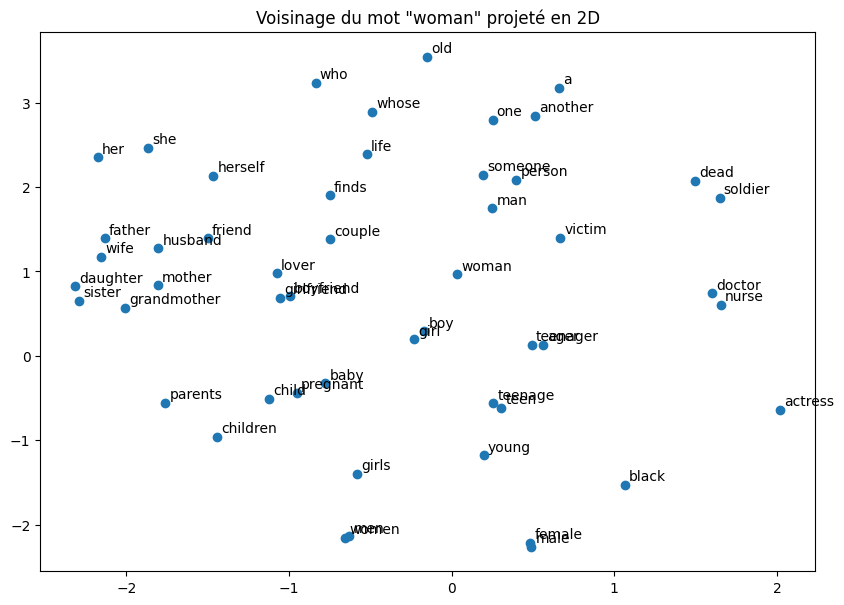

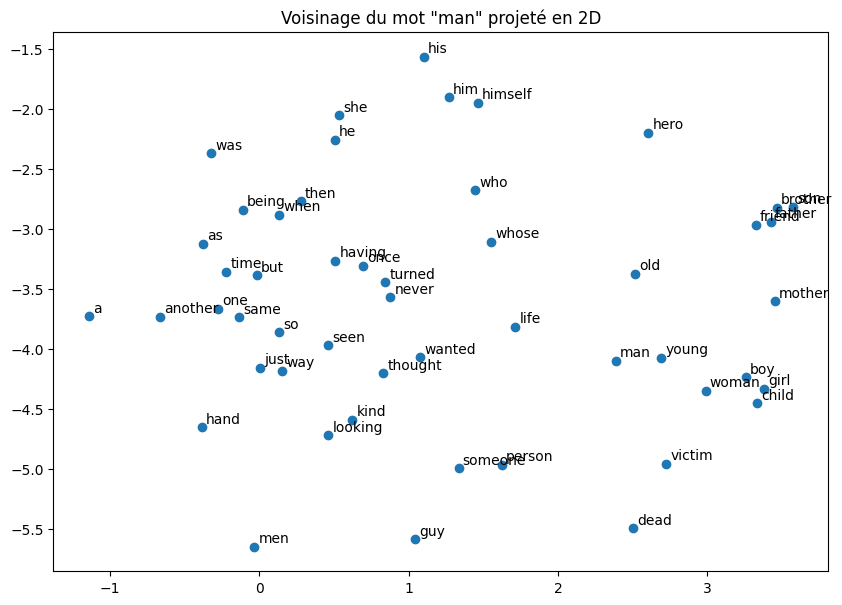

In [35]:
# Voisinage du mot "woman"
afficher_voisinage_tsne(modele, 'woman', taille=50)

# Voisinage du mot "man"
afficher_voisinage_tsne(modele, 'man', taille=50)

### Mots associés à un seul des deux genres

Beaucoup de mots sont proches **à la fois** de "woman" et de "man" (par exemple "person", "young", "old"...). Ces mots-là sont neutres et ne nous intéressent pas pour étudier le biais.

Ce qui est révélateur, c'est de regarder les mots qui sont proches **uniquement** de l'un des deux : ce sont eux qui révèlent les associations stéréotypées du modèle.


In [36]:
# On récupère les 1000 mots les plus proches de "woman" et de "man"
mots_proches_femme = modele.most_similar("woman", topn=1000)
mots_proches_homme = modele.most_similar("man", topn=1000)

# On extrait juste les mots (sans les scores) pour pouvoir comparer les listes
liste_femme = [mot for mot, _score in mots_proches_femme]
liste_homme = [mot for mot, _score in mots_proches_homme]

# On garde uniquement les mots associés à "woman" mais PAS à "man"
uniquement_femme = [(mot, score) for mot, score in mots_proches_femme if mot not in liste_homme]

# Et l'inverse : associés à "man" mais PAS à "woman"
uniquement_homme = [(mot, score) for mot, score in mots_proches_homme if mot not in liste_femme]

print("10 mots associés UNIQUEMENT à 'woman' :")
for mot, score in uniquement_femme[0:10]:
    print(f"  {mot:20s} (similarité : {score:.4f})")

print()
print("10 mots associés UNIQUEMENT à 'man' :")
for mot, score in uniquement_homme[0:10]:
    print(f"  {mot:20s} (similarité : {score:.4f})")

10 mots associés UNIQUEMENT à 'woman' :
  man                  (similarité : 0.8323)
  nurse                (similarité : 0.6139)
  actress              (similarité : 0.6094)
  elderly              (similarité : 0.6047)
  birth                (similarité : 0.5949)
  married              (similarité : 0.5912)
  daughters            (similarité : 0.5891)
  toddler              (similarité : 0.5866)
  sex                  (similarité : 0.5851)
  housewife            (similarité : 0.5679)

10 mots associés UNIQUEMENT à 'man' :
  woman                (similarité : 0.8323)
  "                    (similarité : 0.6067)
  real                 (similarité : 0.5931)
  big                  (similarité : 0.5844)
  crazy                (similarité : 0.5747)
  '                    (similarité : 0.5676)
  boss                 (similarité : 0.5612)
  playing              (similarité : 0.5611)
  player               (similarité : 0.5592)
  things               (similarité : 0.5574)


On peut aussi visualiser ces mots avec t-SNE :

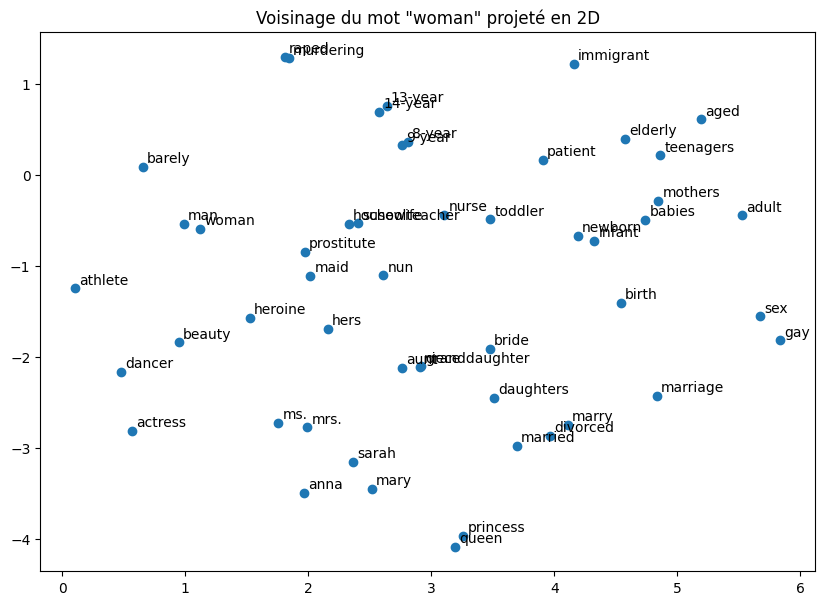

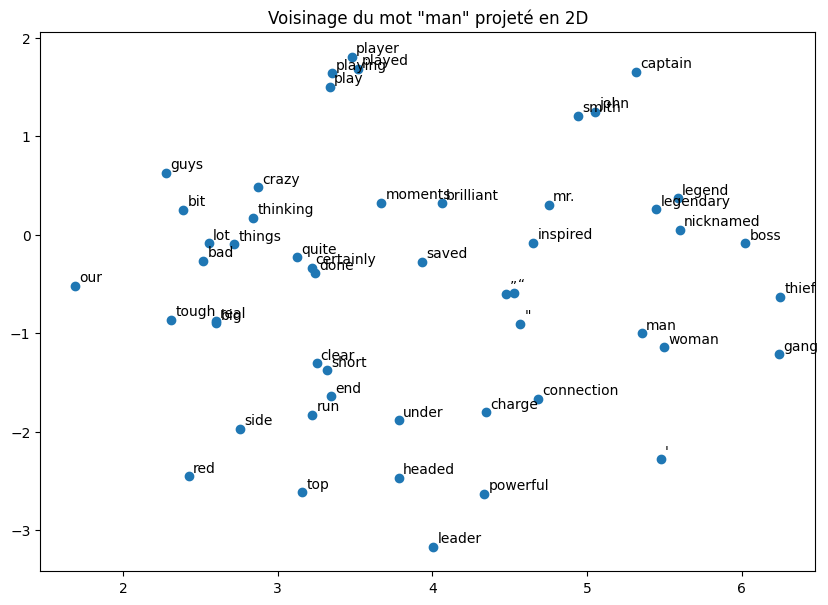

In [37]:
# Voisinage 2D des mots associés UNIQUEMENT à "woman"
afficher_voisinage_tsne(modele, 'woman', uniquement_femme[0:50])

# Voisinage 2D des mots associés UNIQUEMENT à "man"
afficher_voisinage_tsne(modele, 'man', uniquement_homme[0:50])

Ou en diagramme en barres horizontales, ce qui permet de voir la similarité exacte de chaque mot :

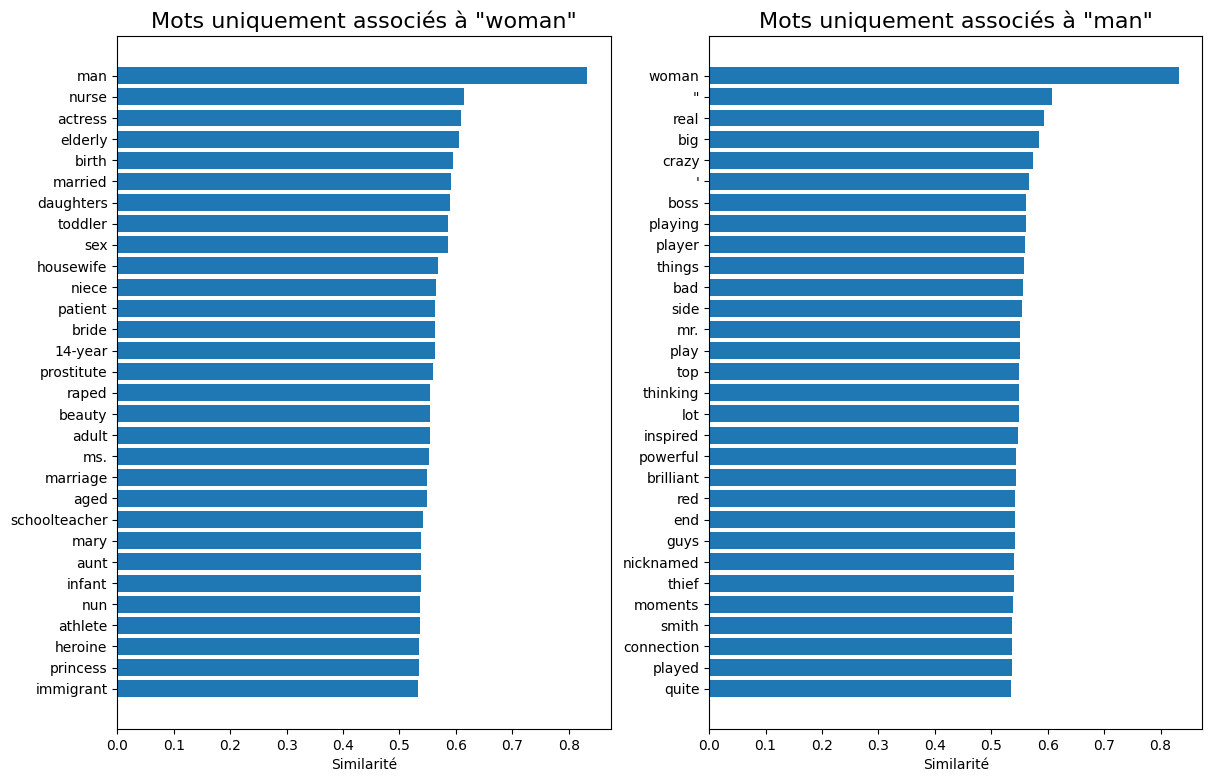

In [38]:
def tracer_barres_horizontales(numero_subplot, titre, mots, scores):
    """
    Trace un diagramme en barres horizontales pour une liste de mots et leurs scores
    de similarité. À utiliser dans une figure à plusieurs subplots.
    """
    plt.subplot(1, 2, numero_subplot)
    plt.barh(mots, scores)
    plt.title(titre, fontsize=16)
    plt.xlabel('Similarité')
    plt.gca().invert_yaxis()  # Pour avoir le mot le plus similaire en haut


# On prend les 30 premiers mots de chaque liste
nb_mots = 30
mots_f   = [mot   for mot, _     in uniquement_femme[:nb_mots]]
scores_f = [score for _, score   in uniquement_femme[:nb_mots]]

mots_h   = [mot   for mot, _     in uniquement_homme[:nb_mots]]
scores_h = [score for _, score   in uniquement_homme[:nb_mots]]

# Affichage des deux diagrammes côte à côte
fig = plt.figure(figsize=(14, 9))
fig.tight_layout(pad=4)
tracer_barres_horizontales(1, 'Mots uniquement associés à "woman"', mots_f, scores_f)
tracer_barres_horizontales(2, 'Mots uniquement associés à "man"',   mots_h, scores_h)
plt.show()

### Tester d'autres associations

On peut mesurer directement la similarité entre **n'importe quels deux mots** avec la fonction `similarity`.

Cela permet de tester des associations précises : est-ce que `"woman"` est plus proche de `"good"` ou de `"bad"` ? Et `"man"` ?


In [39]:
# On compare la similarité de "woman" et "man" avec un même mot test
mot_test = "good"

similarite_femme = modele.similarity('woman', mot_test)
similarite_homme = modele.similarity('man',   mot_test)

print(f'Similarité entre "woman" et "{mot_test}" : {similarite_femme:.4f}')
print(f'Similarité entre "man"   et "{mot_test}" : {similarite_homme:.4f}')

Similarité entre "woman" et "good" : 0.4987
Similarité entre "man"   et "good" : 0.6494


> 🔬 **À vous de jouer** : modifiez la valeur de `mot_test` ci-dessus et essayez d'autres mots, puis ré-exécutez la cellule. Suggestions :
> `intelligent`, `beautiful`, `strong`, `weak`, `rich`, `dangerous`, `kind`, `aggressive`, `smart`, `successful`...
>
> Notez les résultats les plus marquants dans votre fiche élève.


---
## Activité 4 — Les analogies vectorielles

Le modèle GloVe permet de faire des **calculs avec des mots**. Par exemple, on peut demander :

> *« job est à man ce que ___ est à woman ? »*

Ce qui s'écrit mathématiquement :
$$\overrightarrow{job} + \overrightarrow{man} - \overrightarrow{woman} = ?$$

Le modèle nous renvoie les mots dont le vecteur est le plus proche du résultat de ce calcul.

C'est avec ce genre de calcul qu'on peut révéler la fameuse analogie :

> *« roi - homme + femme ≈ reine »*


In [40]:
# Calcul : job + man − woman
# = quel "métier" le modèle associe-t-il à "man" plutôt qu'à "woman" ?
modele.most_similar(positive=['job', 'man'], negative=['woman'], topn=10)

[('good', 0.7210462093353271),
 ('manager', 0.7160085439682007),
 ('better', 0.714841365814209),
 ('going', 0.6982935070991516),
 ('we', 0.693646252155304),
 ('time', 0.6922047138214111),
 ('done', 0.6912675499916077),
 ('doing', 0.6910463571548462),
 ('work', 0.685617983341217),
 ('lot', 0.6833739280700684)]

In [41]:
# Calcul inverse : job + woman − man
# = quel "métier" le modèle associe-t-il à "woman" plutôt qu'à "man" ?
modele.most_similar(positive=['job', 'woman'], negative=['man'], topn=10)

[('jobs', 0.7204642295837402),
 ('employment', 0.6515893936157227),
 ('care', 0.6439723968505859),
 ('hiring', 0.6385829448699951),
 ('nursing', 0.6178941130638123),
 ('working', 0.6053810715675354),
 ('she', 0.6029067039489746),
 ('applicants', 0.5846925973892212),
 ('doing', 0.5785295963287354),
 ('staff', 0.577949047088623)]

> ❓ **À discuter** : les deux listes sont-elles équivalentes en prestige et en autonomie ? Que disent-elles des biais que le modèle a appris ?


---
## Activité 5 — Tentative de débiaisage

Maintenant qu'on a constaté les biais, peut-on les **enlever** ?

L'idée est géométrique :
1. On définit une **« direction du genre »** dans l'espace des vecteurs : c'est la différence entre les vecteurs de `"man"` et `"woman"`.
2. Pour chaque mot (par exemple `"doctor"`), on retire la composante de son vecteur qui pointe dans cette direction.
3. Les vecteurs ainsi nettoyés ne devraient plus avoir d'association avec le genre.

C'est une technique proposée par **Bolukbasi et al. (2016)**, des chercheurs de Microsoft et de l'Université de Boston.


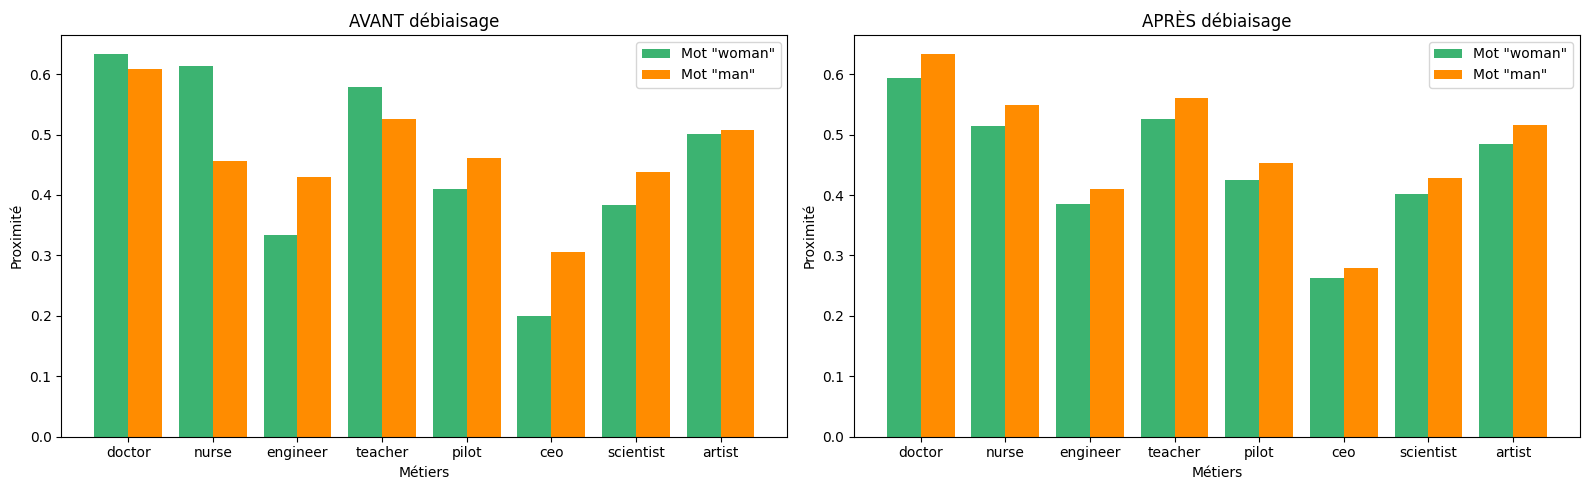

In [42]:
# Étape 1 : on calcule l'axe du genre = vecteur(man) - vecteur(woman)
axe_genre = modele['man'] - modele['woman']

# On le normalise pour qu'il soit de longueur 1 (vecteur unitaire)
axe_genre = axe_genre / np.linalg.norm(axe_genre)

# Étape 2 : on définit une fonction qui retire la composante de genre d'un mot
def retirer_genre(mot):
    """
    Retire la composante de genre du vecteur d'un mot, en projetant le vecteur
    sur l'axe du genre puis en soustrayant cette projection.
    """
    vecteur = modele[mot]
    # Projection du vecteur sur l'axe du genre (produit scalaire × axe)
    composante_genre = np.dot(vecteur, axe_genre) * axe_genre
    # On retire cette composante du vecteur d'origine
    return vecteur - composante_genre

# Étape 3 : on applique le débiaisage à tous les métiers
metiers_neutralises = [retirer_genre(metier) for metier in metiers]

# On recalcule les proximités après débiaisage
# (on utilise cosine_similarities au lieu de distances car nos métiers sont maintenant
#  des vecteurs personnalisés et plus des mots du modèle)
proximite_femme_neutre = modele.cosine_similarities(modele["woman"], metiers_neutralises)
proximite_homme_neutre = modele.cosine_similarities(modele["man"],   metiers_neutralises)


# Affichage côte à côte : AVANT / APRÈS débiaisage
fig = plt.figure(figsize=(16, 5))
largeur = 0.4

# Graphique de gauche : AVANT débiaisage
plt.subplot(1, 2, 1)
plt.bar(metiers, proximite_femme, -largeur, align='edge', color='mediumseagreen', label='Mot "woman"')
plt.bar(metiers, proximite_homme, +largeur, align='edge', color='darkorange',    label='Mot "man"')
plt.xlabel('Métiers')
plt.ylabel('Proximité')
plt.title('AVANT débiaisage')
plt.legend()

# Graphique de droite : APRÈS débiaisage
plt.subplot(1, 2, 2)
plt.bar(metiers, proximite_femme_neutre, -largeur, align='edge', color='mediumseagreen', label='Mot "woman"')
plt.bar(metiers, proximite_homme_neutre, +largeur, align='edge', color='darkorange',    label='Mot "man"')
plt.xlabel('Métiers')
plt.ylabel('Proximité')
plt.title('APRÈS débiaisage')
plt.legend()

plt.tight_layout()
plt.show()

> ❓ **À discuter** : le biais a-t-il vraiment **disparu**, ou seulement été **masqué** ?
>
> En 2019, les chercheuses Hila Gonen et Yoav Goldberg ont montré (dans un article intitulé *Lipstick on a Pig*) que cette méthode de débiaisage rend le biais invisible **à la surface**, mais que les mots restent regroupés selon leurs anciennes associations de genre dans l'espace vectoriel. **Le problème est plus profond qu'il n'y paraît.**


---
## Conclusion

Vous venez d'observer **expérimentalement** trois choses fondamentales :

1. Les modèles de langage apprennent à partir de **textes humains** — et reflètent fidèlement leurs régularités, y compris les stéréotypes.
2. **Détecter** ces biais est techniquement simple : quelques lignes de code suffisent.
3. Les **corriger réellement** est beaucoup plus difficile : retirer un axe de biais en surface ne supprime pas les associations en profondeur.

Ces mêmes principes sont à l'œuvre dans les **grands modèles de langage modernes** (ChatGPT, Claude, Gemini, Mistral...) qui sont entraînés sur des quantités de textes encore plus grandes. Les entreprises qui les développent travaillent activement sur ces questions, mais le problème est loin d'être résolu — et il s'étend bien au-delà du genre (origine ethnique, âge, religion, classe sociale...).

### Pour aller plus loin

📚 Articles scientifiques :
- Bolukbasi et al. (2016), *Man is to Computer Programmer as Woman is to Homemaker? Debiasing Word Embeddings*
- Caliskan et al. (2017), *Semantics derived automatically from language corpora contain human-like biases* (Science)
- Gonen & Goldberg (2019), *Lipstick on a Pig: Debiasing Methods Cover up Systematic Gender Biases*

🎬 Vidéo :
- *Coded Bias* (2020) — documentaire Netflix sur les biais des systèmes d'IA.


In [44]:
!pip freeze > requirements.txt
!pip list --format=freeze > requirements.txt